WEEK 1-2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/smart_home_energy_consumption_large.csv', encoding='latin1')
display(df.head())


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (ï¿½ï,Season,Household Size
0,94,Fridge,0.20,21:12,02-12-2023,-1.0,Fall,2
1,435,Oven,0.23,20:11,06-08-2023,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,21-11-2023,21.3,Fall,3
3,496,Heater,3.92,21:56,21-01-2023,-4.2,Winter,1
4,137,Microwave,0.44,04:31,26-08-2023,34.5,Summer,5


In [ ]:
df.describe()

,Home ID,Energy Consumption (kWh),Outdoor Temperature (ï¿½ï,Household Size
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,250.374980,1.499952,14.950135,3.001770
std,144.435367,1.181176,14.438755,1.417077
min,1.000000,0.100000,-10.000000,1.000000
25%,125.000000,0.590000,2.400000,2.000000
50%,250.000000,1.230000,14.900000,3.000000
75%,375.000000,1.870000,27.400000,4.000000
max,500.000000,5.000000,40.000000,5.000000


In [ ]:
df.shape
df.columns


Index(['Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date',
       'Outdoor Temperature (ï¿½ï', 'Season', 'Household Size'],
      dtype='object')

In [ ]:
# --- Date Conversion ---
if df['Date'].dtype == 'object':
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# --- Time Conversion ---
if 'Hour' not in df.columns:
    df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

print("Date & Hour conversion successful.")
print(df[['Date', 'Time', 'Hour']].head())
print("Data types:\n", df.dtypes)




Date & Hour conversion successful.
        Date   Time  Hour
0 2023-12-02  21:12    21
1 2023-08-06  20:11    20
2 2023-11-21  06:39     6
3 2023-01-21  21:56    21
4 2023-08-26  04:31     4
Data types:
 Home ID                               int64
Appliance Type                       object
Energy Consumption (kWh)            float64
Time                                 object
Date                         datetime64[ns]
Outdoor Temperature (ï¿½ï           float64
Season                               object
Household Size                        int64
Hour                                  int32
dtype: object


In [ ]:
print("Data types after conversion:\n")
print(df.dtypes)


Data types after conversion:

Home ID                               int64
Appliance Type                       object
Energy Consumption (kWh)            float64
Time                                 object
Date                         datetime64[ns]
Outdoor Temperature (ï¿½ï           float64
Season                               object
Household Size                        int64
Hour                                  int32
dtype: object


In [ ]:
print("Missing values per column:\n")
print(df.isnull().sum())



Missing values per column:

Home ID                      0
Appliance Type               0
Energy Consumption (kWh)     0
Time                         0
Date                         0
Outdoor Temperature (ï¿½ï    0
Season                       0
Household Size               0
Hour                         0
dtype: int64


In [ ]:
df['Timestamp'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time']
)

print("Timestamp column created")
df[['Date', 'Time', 'Timestamp']].head()


Timestamp column created


,Date,Time,Timestamp
0,2023-12-02,21:12,2023-12-02 21:12:00
1,2023-08-06,20:11,2023-08-06 20:11:00
2,2023-11-21,06:39,2023-11-21 06:39:00
3,2023-01-21,21:56,2023-01-21 21:56:00
4,2023-08-26,04:31,2023-08-26 04:31:00


In [ ]:
df = df.sort_values(by=['Home ID', 'Timestamp'])

print("Dataset sorted by Home ID and Timestamp")
df[['Home ID', 'Timestamp']].head()


Dataset sorted by Home ID and Timestamp


,Home ID,Timestamp
70905,1,2023-01-05 11:04:00
39488,1,2023-01-07 06:30:00
28058,1,2023-01-07 09:03:00
14540,1,2023-01-08 11:58:00
87480,1,2023-01-10 09:21:00


Outlier Removal Completed 
Rows before outlier removal: 100000
Rows after outlier removal:  92003
Outliers removed:           7997


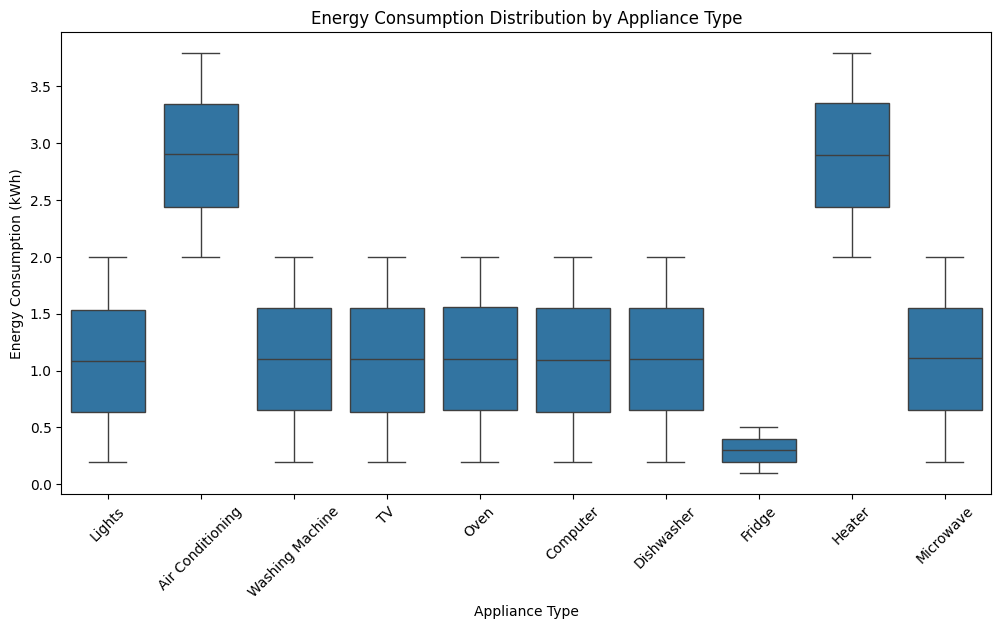

In [ ]:

before = df.shape[0]

Q1 = df['Energy Consumption (kWh)'].quantile(0.25)
Q3 = df['Energy Consumption (kWh)'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['Energy Consumption (kWh)'] >= Q1 - 1.5 * IQR) &
    (df['Energy Consumption (kWh)'] <= Q3 + 1.5 * IQR)
]

after = df.shape[0]


print("Outlier Removal Completed ")
print(f"Rows before outlier removal: {before}")
print(f"Rows after outlier removal:  {after}")
print(f"Outliers removed:           {before - after}")


plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Appliance Type',
    y='Energy Consumption (kWh)',
    data=df
)

plt.xlabel('Appliance Type')
plt.ylabel('Energy Consumption (kWh)')
plt.title('Energy Consumption Distribution by Appliance Type')
plt.xticks(rotation=45)

plt.show()


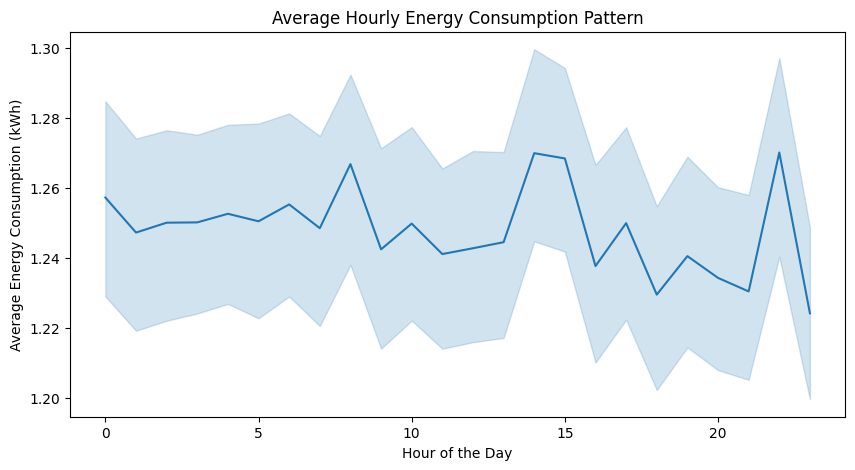

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x='Hour',
    y='Energy Consumption (kWh)',
    data=df,
    estimator='mean'
)

plt.xlabel('Hour of the Day')
plt.ylabel('Average Energy Consumption (kWh)')
plt.title('Average Hourly Energy Consumption Pattern')

plt.show()


In [ ]:

scaler = StandardScaler()
df['Energy_scaled'] = scaler.fit_transform(
    df[['Energy Consumption (kWh)']]
)

print("Energy values scaled ")
df[['Energy Consumption (kWh)', 'Energy_scaled']].head()


Energy values scaled 


,Energy Consumption (kWh),Energy_scaled
70905,0.91,-0.400450
39488,2.77,1.802397
14540,1.70,0.535168
87480,0.70,-0.649159
71411,1.21,-0.045152


In [ ]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

print("Time-based features added")
df[['Date', 'Day', 'Month', 'Weekday']].head()


Time-based features added


,Date,Day,Month,Weekday
70905,2023-01-05,5,1,3
39488,2023-01-07,7,1,5
14540,2023-01-08,8,1,6
87480,2023-01-10,10,1,1
71411,2023-01-12,12,1,3


In [ ]:
df_ml = pd.get_dummies(
    df,
    columns=['Appliance Type', 'Season'],
    drop_first=True
)

print("Categorical encoding done ")
print("Shape after encoding:", df_ml.shape)


Categorical encoding done 
Shape after encoding: (92003, 24)


In [ ]:
df_ml = df_ml.drop(['Time', 'Timestamp'], axis=1)

print("Dropped unused columns")
print("Remaining columns:\n", df_ml.columns)


Dropped unused columns
Remaining columns:
 Index(['Home ID', 'Energy Consumption (kWh)', 'Date',
       'Outdoor Temperature (ï¿½ï', 'Household Size', 'Hour', 'Energy_scaled',
       'Day', 'Month', 'Weekday', 'Appliance Type_Computer',
       'Appliance Type_Dishwasher', 'Appliance Type_Fridge',
       'Appliance Type_Heater', 'Appliance Type_Lights',
       'Appliance Type_Microwave', 'Appliance Type_Oven', 'Appliance Type_TV',
       'Appliance Type_Washing Machine', 'Season_Spring', 'Season_Summer',
       'Season_Winter'],
      dtype='object')


In [ ]:
X = df_ml.drop('Energy Consumption (kWh)', axis=1)
y = df_ml['Energy Consumption (kWh)']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (92003, 21)
Target vector shape: (92003,)


1)Energy_scaled was created directly from the target variable Energy Consumption (kWh) using StandardScaler. That means it contains the exact same information, just transformed. If you keep it in X, the model is basically predicting the target using a modified version of itself.

That leads to:

Perfect MAE = 0

Perfect RMSE = 0

R² = 1.0

Unrealistic performance

This is called data leakage, and it makes the model invalid.

So removing Energy_scaled was the right decision because:

It prevents leakage

It ensures fair training

It produces realistic evaluation metrics


2)Machine learning models like Linear Regression and Random Forest cannot directly understand datetime values.

Date is not a meaningful numerical feature by itself.

You already extracted useful information from it:

Day

Month

Weekday

Hour

These extracted features capture the time patterns properly.

If you keep raw Date:

It causes dtype errors (datetime issue you saw earlier).

It does not help prediction unless converted into useful components.


In [ ]:
X = X.drop(columns=['Date'], errors='ignore')
X = X.drop(columns=['Energy_scaled'], errors='ignore')


# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Dataset split completed \n")

print("Training set size:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)

print("\nValidation set size:")
print("X_val:", X_val.shape, "y_val:", y_val.shape)

print("\nTest set size:")
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Dataset split completed 

Training set size:
X_train: (64402, 19) y_train: (64402,)

Validation set size:
X_val: (13800, 19) y_val: (13800,)

Test set size:
X_test: (13801, 19) y_test: (13801,)


In [ ]:
print("Feature Matrix (X) Preview:")
display(X.head())

Feature Matrix (X) Preview:


,Home ID,Outdoor Temperature (ï¿½ï,Household Size,Hour,Day,Month,Weekday,Appliance Type_Computer,Appliance Type_Dishwasher,Appliance Type_Fridge,Appliance Type_Heater,Appliance Type_Lights,Appliance Type_Microwave,Appliance Type_Oven,Appliance Type_TV,Appliance Type_Washing Machine,Season_Spring,Season_Summer,Season_Winter
70905,1,13.4,2,11,5,1,3,False,False,False,False,True,False,False,False,False,False,False,True
39488,1,-3.3,3,6,7,1,5,False,False,False,False,False,False,False,False,False,False,False,True
14540,1,17.5,3,11,8,1,6,False,False,False,False,False,False,False,False,True,False,False,True
87480,1,29.5,1,9,10,1,1,False,False,False,False,False,False,False,True,False,False,False,True
71411,1,0.6,5,16,12,1,3,False,False,False,False,True,False,False,False,False,False,False,True


WEEK 3-4

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully ")


Linear Regression model trained successfully 


In [ ]:
# Predictions
y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)
y_test_pred = lr_model.predict(X_test)

print("Predictions completed ")


Predictions completed 


In [ ]:
# Evaluation on Test Set

lr_mae = mean_absolute_error(y_test, y_test_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
lr_r2 = r2_score(y_test, y_test_pred)

print("Baseline Model Performance (Test Set)")
print("MAE :", round(lr_mae, 4))
print("RMSE:", round(lr_rmse, 4))
print("R2  :", round(lr_r2, 4))


Baseline Model Performance (Test Set)
MAE : 0.4104
RMSE: 0.4904
R2  : 0.6639


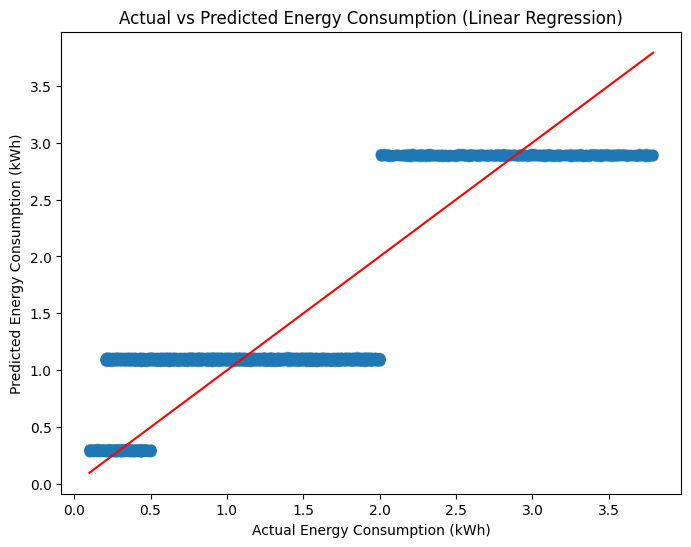

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred, alpha=0.4)
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption (Linear Regression)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients.head(10)


,Feature,Coefficient
4,Day,0.000028
0,Home ID,-0.000010
1,Outdoor Temperature (ï¿½ï,-0.000082
3,Hour,-0.000211
6,Weekday,-0.000568
16,Season_Spring,-0.001122
5,Month,-0.001488
10,Appliance Type_Heater,-0.001966
2,Household Size,-0.003432
17,Season_Summer,-0.006343


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)



In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.410420,0.49036,0.663869
1,Random Forest,0.417403,0.50310,0.646176


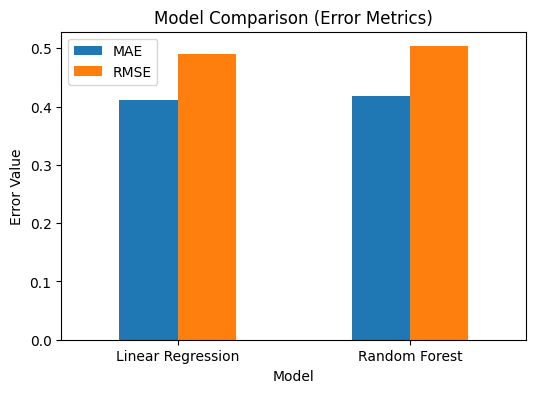

In [ ]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Model Comparison (Error Metrics)")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.show()


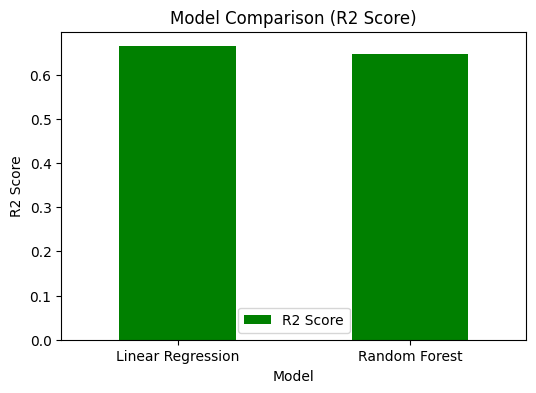

In [ ]:
comparison.set_index("Model")[["R2 Score"]].plot(
    kind='bar',
    figsize=(6,4),
    color='green'
)

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.show()


In [ ]:
df_ml = df_ml.drop(columns=["Energy_scaled"], errors="ignore")

DATA PREVIEW

In [ ]:
print("Final ML Dataset Preview:")
display(df_ml.head())

Final ML Dataset Preview:


,Home ID,Energy Consumption (kWh),Date,Outdoor Temperature (ï¿½ï,Household Size,Hour,Day,Month,Weekday,Appliance Type_Computer,...,Appliance Type_Fridge,Appliance Type_Heater,Appliance Type_Lights,Appliance Type_Microwave,Appliance Type_Oven,Appliance Type_TV,Appliance Type_Washing Machine,Season_Spring,Season_Summer,Season_Winter
70905,1,0.91,2023-01-05,13.4,2,11,5,1,3,False,...,False,False,True,False,False,False,False,False,False,True
39488,1,2.77,2023-01-07,-3.3,3,6,7,1,5,False,...,False,False,False,False,False,False,False,False,False,True
14540,1,1.70,2023-01-08,17.5,3,11,8,1,6,False,...,False,False,False,False,False,False,True,False,False,True
87480,1,0.70,2023-01-10,29.5,1,9,10,1,1,False,...,False,False,False,False,False,True,False,False,False,True
71411,1,1.21,2023-01-12,0.6,5,16,12,1,3,False,...,False,False,True,False,False,False,False,False,False,True


In [ ]:
print("Feature Matrix (X) Preview:")
display(X.head())


Feature Matrix (X) Preview:


,Home ID,Outdoor Temperature (ï¿½ï,Household Size,Hour,Day,Month,Weekday,Appliance Type_Computer,Appliance Type_Dishwasher,Appliance Type_Fridge,Appliance Type_Heater,Appliance Type_Lights,Appliance Type_Microwave,Appliance Type_Oven,Appliance Type_TV,Appliance Type_Washing Machine,Season_Spring,Season_Summer,Season_Winter
70905,1,13.4,2,11,5,1,3,False,False,False,False,True,False,False,False,False,False,False,True
39488,1,-3.3,3,6,7,1,5,False,False,False,False,False,False,False,False,False,False,False,True
14540,1,17.5,3,11,8,1,6,False,False,False,False,False,False,False,False,True,False,False,True
87480,1,29.5,1,9,10,1,1,False,False,False,False,False,False,False,True,False,False,False,True
71411,1,0.6,5,16,12,1,3,False,False,False,False,True,False,False,False,False,False,False,True


In [ ]:
print("Target Variable (y) Preview:")
display(y.head())


Target Variable (y) Preview:


,Energy Consumption (kWh)
70905,0.91
39488,2.77
14540,1.70
87480,0.70
71411,1.21


In [ ]:
print("Training Data Preview:")
display(X_train.head())


Training Data Preview:


,Home ID,Outdoor Temperature (ï¿½ï,Household Size,Hour,Day,Month,Weekday,Appliance Type_Computer,Appliance Type_Dishwasher,Appliance Type_Fridge,Appliance Type_Heater,Appliance Type_Lights,Appliance Type_Microwave,Appliance Type_Oven,Appliance Type_TV,Appliance Type_Washing Machine,Season_Spring,Season_Summer,Season_Winter
12163,46,0.4,2,16,12,11,6,False,False,False,False,False,False,False,False,True,False,False,False
96801,72,32.8,1,7,7,12,3,False,False,False,False,False,False,True,False,False,False,False,False
32041,165,13.6,4,5,11,1,2,False,True,False,False,False,False,False,False,False,False,False,True
25081,254,18.4,4,6,12,2,6,False,False,False,False,False,False,False,False,True,False,False,True
92879,372,14.9,5,10,22,12,4,False,False,False,False,False,True,False,False,False,False,False,False


WEEK 5-6

In [ ]:
import numpy as np

sequence_length = 24
X_seq = []
y_seq = []

# Sort by Home ID and Date
df_sorted = df_ml.sort_values(by=["Home ID", "Date"])

features = X.columns
target = "Energy Consumption (kWh)"

# Convert all features to float
df_sorted[features] = df_sorted[features].astype(float)

for home in df_sorted["Home ID"].unique():

    home_data = df_sorted[df_sorted["Home ID"] == home]

    for i in range(len(home_data) - sequence_length):
        X_seq.append(home_data[features].iloc[i:i+sequence_length].values)
        y_seq.append(home_data[target].iloc[i+sequence_length])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)

print("New Sequence Shape:", X_seq.shape)


New Sequence Shape: (80003, 24, 19)


In [ ]:
split = int(0.8 * len(X_seq))

X_train_seq = X_seq[:split]
X_test_seq = X_seq[split:]

y_train_seq = y_seq[:split]
y_test_seq = y_seq[split:]

print("Train shape:", X_train_seq.shape)
print("Test shape:", X_test_seq.shape)


Train shape: (64002, 24, 19)
Test shape: (16001, 24, 19)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │        75,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,297 (497.25 KB)

 Trainable params: 127,297 (497.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=40,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 64s 64ms/step - loss: 0.7726 - mae: 0.6931 - val_loss: 0.7502 - val_mae: 0.6665
Epoch 2/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - loss: 0.7268 - mae: 0.6740 - val_loss: 0.7214 - val_mae: 0.6724
Epoch 3/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 61s 67ms/step - loss: 0.7177 - mae: 0.6738 - val_loss: 0.7308 - val_mae: 0.6659
Epoch 4/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 57s 64ms/step - loss: 0.7116 - mae: 0.6690 - val_loss: 0.7215 - val_mae: 0.6736
Epoch 5/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - loss: 0.7315 - mae: 0.6799 - val_loss: 0.7304 - val_mae: 0.6659
Epoch 6/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 53s 59ms/step - loss: 0.7117 - mae: 0.6701 - val_loss: 0.7218 - val_mae: 0.6703
Epoch 7/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 74s 50ms/step - loss: 0.7107 - mae: 0.6709 - val_loss: 0.7219 - val_mae: 0.6702
Epoch 8/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 47s 52ms/step - loss: 0.7227 - mae: 0.6754 - val_loss: 0.7495 - val_mae: 0.6664
Epoch 9/40
901/901 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:

y_pred_lstm = model.predict(X_test_seq)

lstm_mae = mean_absolute_error(y_test_seq, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
lstm_r2 = r2_score(y_test_seq, y_pred_lstm)

print("Improved LSTM Performance")
print("MAE:", round(lstm_mae,4))
print("RMSE:", round(lstm_rmse,4))
print("R2:", round(lstm_r2,4))


501/501 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
Improved LSTM Performance
MAE: 0.6658
RMSE: 0.8419
R2: -0.0016


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "LSTM"],
    "MAE": [lr_mae, rf_mae, lstm_mae],
    "RMSE": [lr_rmse, rf_rmse, lstm_rmse],
    "R2 Score": [lr_r2, rf_r2, lstm_r2]
})

comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.410420,0.490360,0.663869
1,Random Forest,0.417403,0.503100,0.646176
2,LSTM,0.665845,0.841876,-0.001570


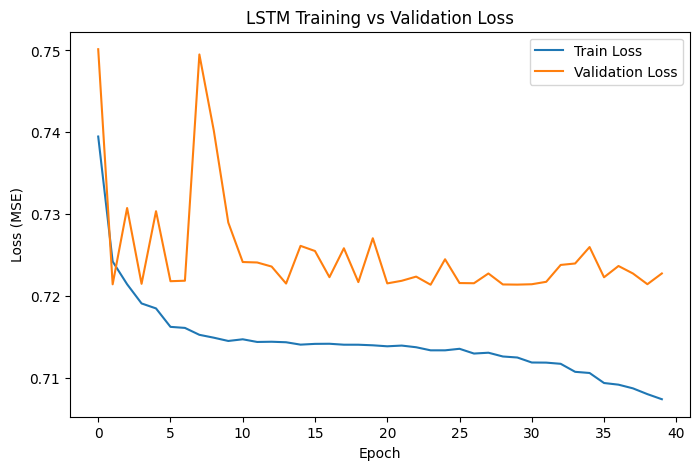

In [ ]:


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()


In [ ]:
import joblib

joblib.dump(lr_model, "best_energy_model.pkl")


['best_energy_model.pkl']

In [ ]:
from google.colab import files
files.download("best_energy_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>